# Analyse de Saisonnalité et Tendances Temporelles
**Objectif :** Détecter les cycles de vente annuels afin d'identifier les périodes de forte activité (pics) et les périodes creuses.

### Intérêt Business :
* **Planification Logistique** : Anticiper les besoins en personnel et en stockage avant les mois de forte demande.
* **Stratégie Marketing** : Lancer des promotions durant les mois faibles pour lisser le chiffre d'affaires.
* **Trésorerie** : Prévoir les flux de rentrées d'argent au cours de l'année.

Extraction des revenus mensuels...


c:\Users\salma\classicmodels-analysis\src\analysis\connection.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


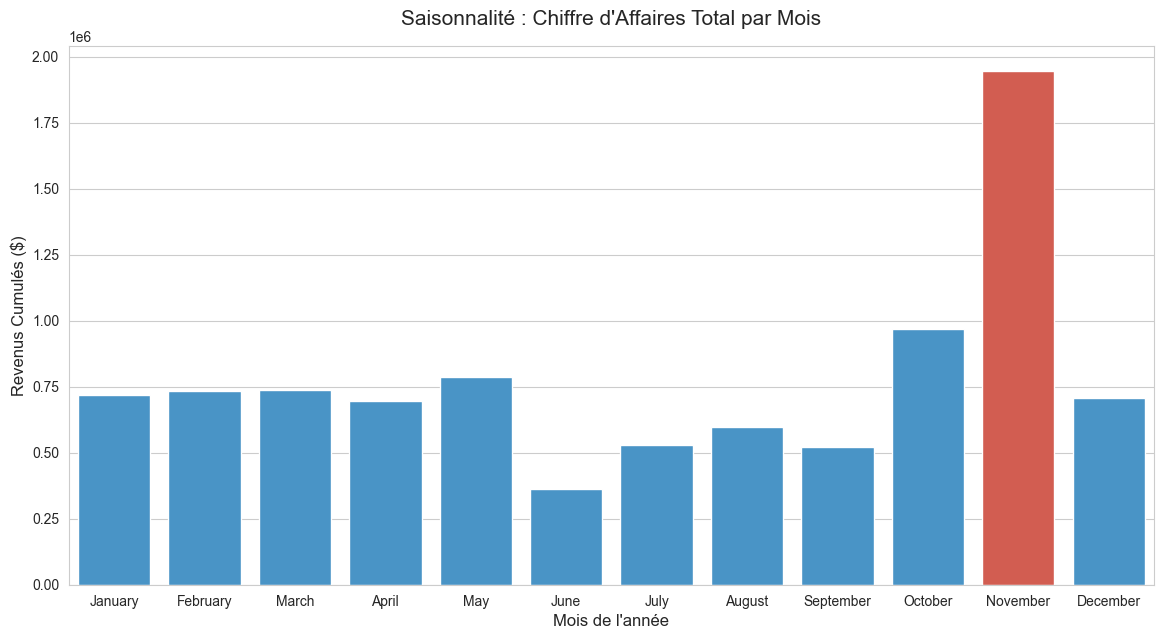

Mois le plus performant : November
Mois le moins performant : June


In [2]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURATION DU CHEMIN
sys.path.append(os.path.abspath(os.path.join('..')))
from src.analysis.connection import get_db_data 

# 2. EXTRACTION DES DONNÉES TEMPORELLES
print("Extraction des revenus mensuels...")
query_seasonality = """
    SELECT 
        orderDate,
        SUM(quantityOrdered * priceEach) AS revenue
    FROM orders
    JOIN orderdetails USING (orderNumber)
    WHERE status NOT IN ('Cancelled', 'Disputed')
    GROUP BY orderDate
"""
df_sales = get_db_data(query_seasonality)

# 3. PRÉPARATION DES DONNÉES
df_sales['orderDate'] = pd.to_datetime(df_sales['orderDate'])
df_sales['month_name'] = df_sales['orderDate'].dt.month_name()
df_sales['month_num'] = df_sales['orderDate'].dt.month

# Agrégation par mois pour voir la tendance saisonnière globale
# On trie par 'month_num' pour garder l'ordre chronologique de Janvier à Décembre
seasonal_data = df_sales.groupby(['month_num', 'month_name'])['revenue'].sum().reset_index()

# 4. VISUALISATION
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Définition d'une palette pour mettre en évidence le mois maximum
max_revenue = seasonal_data['revenue'].max()
palette = ['#e74c3c' if x == max_revenue else '#3498db' for x in seasonal_data['revenue']]

# Création du graphique à barres
sns.barplot(
    data=seasonal_data, 
    x='month_name', 
    y='revenue', 
    palette=palette, 
    hue='month_name', 
    legend=False
)

plt.title('Saisonnalité : Chiffre d\'Affaires Total par Mois', fontsize=15, pad=15)
plt.xlabel('Mois de l\'année', fontsize=12)
plt.ylabel('Revenus Cumulés ($)', fontsize=12)

# Sauvegarde
save_path_season = os.path.join('..', 'visualisations', 'seasonality_analysis.png')
plt.savefig(save_path_season, bbox_inches='tight', dpi=300)
plt.show()

# 5. RÉSULTATS CLÉS
strongest = seasonal_data.loc[seasonal_data['revenue'].idxmax(), 'month_name']
weakest = seasonal_data.loc[seasonal_data['revenue'].idxmin(), 'month_name']
print(f"Mois le plus performant : {strongest}")
print(f"Mois le moins performant : {weakest}")

/ Analyse de Saisonnalité : Diagnostic des Flux et Cycles de Vente

L'objectif de cette étude temporelle est de sortir d'une vision globale pour comprendre la dynamique mensuelle du chiffre d'affaires de ClassicModels. L'identification des cycles saisonniers est un levier majeur pour la planification opérationnelle et financière.

--> Constats de l'Analyse (Tendances de Marché)
Le graphique révèle une saisonnalité marquée, caractérisée par une stabilité relative sur les trois premiers trimestres, suivie d'une accélération brutale en fin d'année.

- Le Phénomène de Novembre : On observe une explosion du chiffre d'affaires en novembre, atteignant près de 2 millions de dollars, soit plus du double de la moyenne des autres mois. Ce pic suggère une concentration massive des commandes, probablement liée aux périodes de fêtes (B2C) ou aux clôtures budgétaires annuelles des détaillants (B2B).

- La Transition d'Octobre : La croissance commence déjà à s'amorcer en octobre (environ 1 million $), marquant le début de la "haute saison".

- Le Creux de Juin : À l'inverse, le mois de juin marque le point le plus bas de l'activité commerciale (moins de 400 000 $). Ce ralentissement estival est classique dans de nombreux secteurs et indique une période de faible sollicitation du marché.

- La Reprise de Décembre : On note une chute immédiate en décembre après le pic de novembre, les ventes revenant au niveau standard de début d'année (environ 700 000 $).